In [19]:
# ---------------------------
# 1. Load Libraries
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import ttest_ind
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.mixed_linear_model import MixedLM
import warnings
warnings.filterwarnings('ignore')

# For Firth logistic regression
#!pip install firthlogist
# Use this instead of firthlogist
from firthmodels import FirthLogisticRegression


# For VIF helper
from statsmodels.tools.tools import add_constant

In [42]:
# ---------------------------
# Data Importing
# ---------------------------

clinical = pd.read_csv("./Copy of ds_take_home_clinical_outcomes.csv - Sheet1.csv")
procedure = pd.read_csv("./ds_take_home_procedure_metrics.csv - Sheet1.csv")

In [43]:
# 1st data checking

print(clinical.shape[0])  # 120 rows
print(clinical.shape[1])  # 5 columns
print(clinical.describe())
print(clinical.info())
print(clinical.head(2))

print(procedure.shape[0])  # 300 rows
print(procedure.shape[1])  # 12 columns
print(procedure.describe())
print(procedure.info())
print(procedure.head(2))

# merging the entire data
outcome_matrix = pd.merge(procedure, clinical, on="procedure_id", how="left")
print(outcome_matrix.shape)  # (300, 16)
print(outcome_matrix.head(10))

120
5
       complication  complete_resection  hospital_stay_days
count    120.000000           82.000000          120.000000
mean       0.091667            0.865854            3.065000
std        0.289765            0.342907            1.091884
min        0.000000            0.000000            1.400000
25%        0.000000            1.000000            2.300000
50%        0.000000            1.000000            2.800000
75%        0.000000            1.000000            3.700000
max        1.000000            1.000000            6.300000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   procedure_id           120 non-null    object 
 1   complication           120 non-null    int64  
 2   complication_severity  11 non-null     object 
 3   complete_resection     82 non-null     float64
 4   hospital_stay_days     120 non-nu

In [ ]:
# data cleaning

print(outcome_matrix.describe())
print(outcome_matrix.info())

# convert column names to snake_case
def clean_names(df):
    df.columns = (df.columns.str.strip()
                  .str.replace(' ', '_')
                  .str.replace('([a-z])([A-Z])', r'\1_\2', regex=True)
                  .str.lower())
    return df

outcome_matrix = clean_names(outcome_matrix)

# NA values checking
print(outcome_matrix.isna().sum())
mean_na = outcome_matrix.isna().mean().mean()
print(mean_na)  # Overall proportion of NA 0.180625 


       procedure_length_min  path_efficiency  movement_smoothness  \
count            300.000000       300.000000           300.000000   
mean             121.423000         0.441083             0.716229   
std               59.680409         0.130806             0.060615   
min               30.100000         0.091600             0.550500   
25%               77.775000         0.351825             0.672375   
50%              110.000000         0.446150             0.712100   
75%              152.600000         0.535750             0.764075   
max              411.800000         0.901700             0.902000   

       idle_time_pct  tool_switching_per_min  site_visibility_pct  \
count     300.000000              300.000000           300.000000   
mean        5.046667               79.621333            87.184000   
std         2.237194               33.665492             6.795465   
min         0.000000                5.000000            62.100000   
25%         3.600000             

In [ ]:

# duplicate check
duplicates = outcome_matrix[outcome_matrix.duplicated()]
print(duplicates)
# no duplicate found 

Empty DataFrame
Columns: [procedure_id, surgeon_id, procedure_length_min, path_efficiency, movement_smoothness, idle_time_pct, tool_switching_per_min, site_visibility_pct, two_tools_pct, speed, workspace_coverage, composite_score, complication, complication_severity, complete_resection, hospital_stay_days]
Index: []


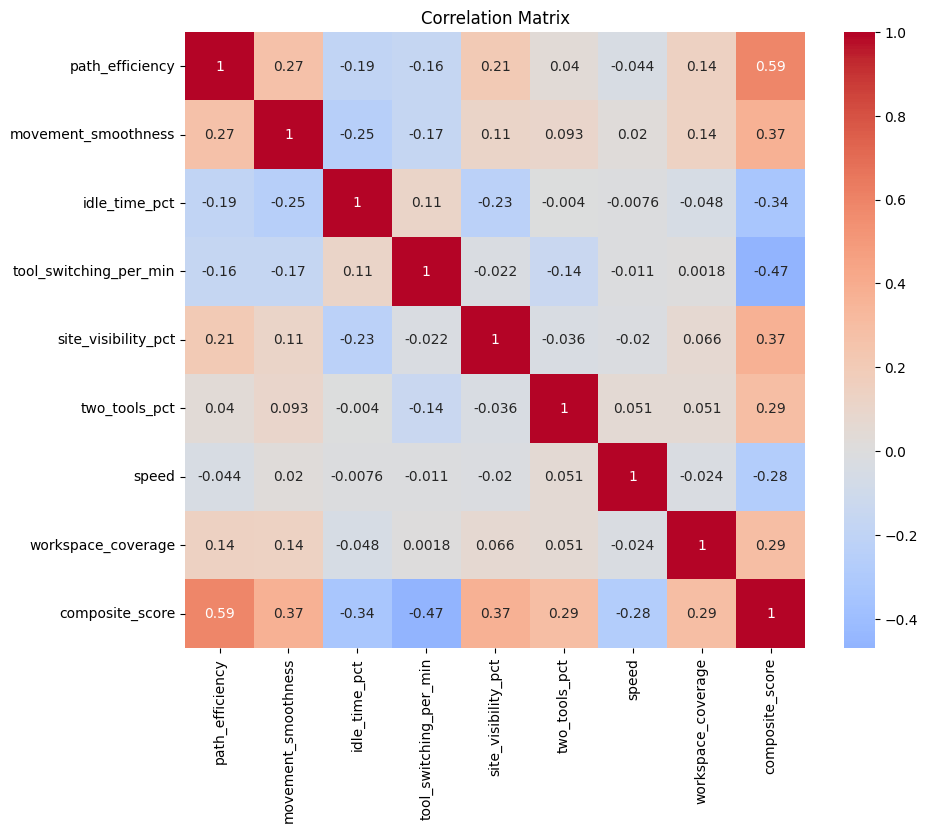

In [46]:
## Correlation Heatmap

metric_col = outcome_matrix[['path_efficiency',
                             'movement_smoothness',
                             'idle_time_pct',
                             'tool_switching_per_min',
                             'site_visibility_pct',
                             'two_tools_pct',
                             'speed',
                             'workspace_coverage',
                             'composite_score']]

M = metric_col.corr()

plt.figure(figsize=(10,8))
sns.heatmap(M, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# The composites score mostly correlates the strongly path efficiency which is .6 percent...

In [47]:
## Over/Under‑weighted Metrics

metric_cols = ["path_efficiency", "movement_smoothness", "idle_time_pct",
               "tool_switching_per_min", "site_visibility_pct", "two_tools_pct",
               "speed", "workspace_coverage"]

# standardise each metric (mean 0, sd 1)
scaler = StandardScaler()
df_std = outcome_matrix.copy()
df_std[metric_cols] = scaler.fit_transform(outcome_matrix[metric_cols])

print(df_std.isna().sum())
mean_na = df_std.isna().mean().mean()
print(mean_na)

procedure_id                0
surgeon_id                  0
procedure_length_min        0
path_efficiency             0
movement_smoothness         0
idle_time_pct               0
tool_switching_per_min      0
site_visibility_pct         0
two_tools_pct               0
speed                       0
workspace_coverage          0
composite_score             0
complication              180
complication_severity     289
complete_resection        218
hospital_stay_days        180
dtype: int64
0.180625


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.006
Model:                            OLS   Adj. R-squared (uncentered):             -0.021
Method:                 Least Squares   F-statistic:                             0.2238
Date:                Mon, 11 May 2026   Prob (F-statistic):                       0.986
Time:                        02:26:25   Log-Likelihood:                         -1676.7
No. Observations:                 300   AIC:                                      3369.
Df Residuals:                     292   BIC:                                      3399.
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

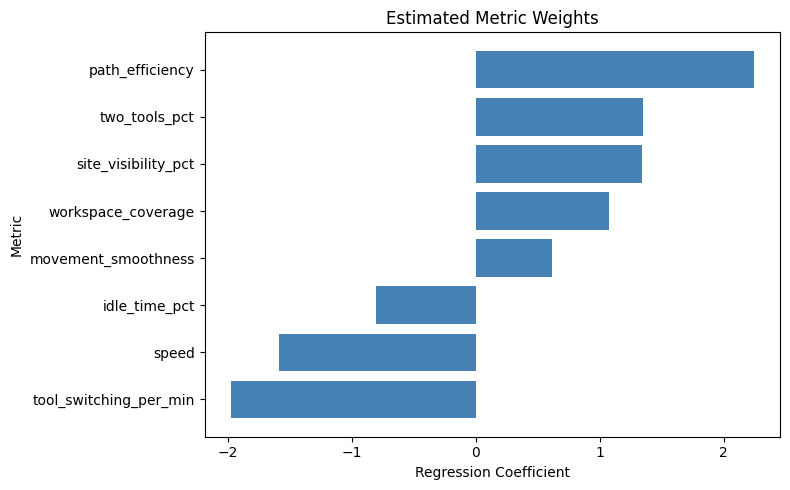

In [ ]:
# Regression on standardized variables

df_std = outcome_matrix.copy()
df_std[metric_cols] = scaler.fit_transform(outcome_matrix[metric_cols])

# Linear regression without intercept (0 + .)
X = df_std[metric_cols].values
y = df_std['composite_score'].values
X = sm.add_constant(X, has_constant='add')  # we will force no intercept by removing const
# Actually to have 0 + ., we remove the constant
X_no_const = df_std[metric_cols].values
model_norm = sm.OLS(y, X_no_const).fit()
print(model_norm.summary())

# Coefficient dataframe
coef_df = pd.DataFrame({
    'term': metric_cols,
    'estimate': model_norm.params
})
coef_df = coef_df.sort_values('estimate')

plt.figure(figsize=(8,5))
plt.barh(coef_df['term'], coef_df['estimate'], color='steelblue')
plt.xlabel('Regression Coefficient')
plt.ylabel('Metric')
plt.title('Estimated Metric Weights')
plt.tight_layout()
plt.show()

# Path Efficiency, two tool percentage, site visibility percentage.

In [ ]:
#----------------------------
# Association with Clinical Outcomes
#----------------------------

df_out = outcome_matrix.dropna(subset=['complication'])

# Logistic regression
X_comp = sm.add_constant(df_out['composite_score'])
logit_comp = sm.Logit(df_out['complication'], X_comp).fit()
print(logit_comp.summary())

# Odds ratio for 10‑point increase
coef_comp = logit_comp.params['composite_score']
odds_ratio_10 = np.exp(coef_comp * 10)
print(odds_ratio_10)

# ---------------------------
# Complete resection
# --------------------------
df_res = outcome_matrix.dropna(subset=['complete_resection'])
X_res = sm.add_constant(df_res['composite_score'])
logit_res = sm.Logit(df_res['complete_resection'], X_res).fit()
print(logit_res.summary())

# ---------------------------
# Hospital stay
# --------------------------
X_hosp = sm.add_constant(df_out['composite_score'])
lm_hosp = sm.OLS(df_out['hospital_stay_days'], X_hosp).fit()
print(lm_hosp.summary())



Optimization terminated successfully.
         Current function value: 0.294799
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           complication   No. Observations:                  120
Model:                          Logit   Df Residuals:                      118
Method:                           MLE   Df Model:                            1
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.03779
Time:                        02:26:26   Log-Likelihood:                -35.376
converged:                       True   LL-Null:                       -36.765
Covariance Type:            nonrobust   LLR p-value:                   0.09552
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.3349      3.815     -2.185      0.029     -15.812      -0.858
composite_scor

In [50]:
# Addressing Confounding variables

# Logistic regression with procedure length
X_conf = df_out[['composite_score', 'procedure_length_min']]
X_conf = sm.add_constant(X_conf)
logit_conf = sm.Logit(df_out['complication'], X_conf).fit()
print(logit_conf.summary())

# Mixed‑effects model with random intercept for surgeon (if surgeon_id exists)
# statsmodels does not support GLMM directly, so we show standard logit and comment.
if 'surgeon_id' in df_out.columns:
    # Mixed Logit is not directly available; using standard logit as approximation
    print("Note: Python statsmodels has no native GLMM. Using fixed-effects logit.")
    # In practice you could use pymer4 or rpy2, but here we keep the same variables
    mixed_logit_fixed = sm.Logit.from_formula('complication ~ composite_score + procedure_length_min', data=df_out).fit()
    print(mixed_logit_fixed.summary())
    print("Random effect variance not available. However, here is the variance from a mixed linear model on a continuous proxy:")

# One can clearly say that the composite score and procedure length...

Optimization terminated successfully.
         Current function value: 0.293786
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           complication   No. Observations:                  120
Model:                          Logit   Df Residuals:                      117
Method:                           MLE   Df Model:                            2
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.04110
Time:                        02:26:26   Log-Likelihood:                -35.254
converged:                       True   LL-Null:                       -36.765
Covariance Type:            nonrobust   LLR p-value:                    0.2207
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -8.5469      3.795     -2.252      0.024     -15.985      -1.109

In [ ]:
# part 2

## 2.1 Surgeon‑level Nesting

# For linear model (hospital stay), use MixedLM
if 'surgeon_id' in df_out.columns:
    mixed_linear = MixedLM.from_formula('hospital_stay_days ~ composite_score', groups=df_out['surgeon_id'], data=df_out)
    mixed_linear_result = mixed_linear.fit()
    print(mixed_linear_result.summary())

    # ICC = variance_surgeon / (variance_surgeon + residual variance)
    var_surgeon = mixed_linear_result.cov_re.iloc[0,0]
    resid_var = mixed_linear_result.scale
    icc = var_surgeon / (var_surgeon + resid_var)
    print(f"ICC for hospital stay: {icc:.3f}")



             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: hospital_stay_days
No. Observations: 120     Method:             REML              
No. Groups:       10      Scale:              1.1263            
Min. group size:  3       Log-Likelihood:     -183.2483         
Max. group size:  28      Converged:          Yes               
Mean group size:  12.0                                          
-----------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept           2.398     1.248  1.922  0.055  -0.047   4.843
composite_score     0.011     0.019  0.555  0.579  -0.027   0.048
Group Var           0.080     0.088                              

ICC for hospital stay: 0.066
